#                                                       **Fresco Retailer Product Return Prediction**


## **Project Cycle:**

1. **Check data quality (Missing & Duplicates)** - Reviewed data types, and verify if it is correct. Also check for missing & duplicate values.

2. **Univariate analysis** — In this step, I went through each column individually to identify and address any issues, and performed EDA to gain a deeper understanding of the features.

3. **Bivariate analysis** — Explored the relationship between each feature and the target variable (Churn) to discover useful patterns.

4. **Multivariate analysis** — Analyzed how multiple features interact together and how they collectively affect churn.

5. **Feature extraction** — Created new features from existing ones to improve the model’s learning capability and overall performance.

6. **Feature importance** — Used correlation and ExtraTreesClassifier to identify the most important features for the model, and removed less impactful ones.

7. **ML Pipelines** —Built separate pipelines for categorical and numerical data to handle missing values, encoding, scaling, and class imbalance automatically — ensuring a clean, repeatable workflow.

8. **Model training** — Trained several machine learning models using cross-validation and pipelines to prevent data leakage and evaluate consistent performance.

9. **Choose best model** — Selected **Xgboost** as the best model based on performance metrics.

10. **Tuning** — Optimized the Xgboost hyperparameters using **random_search**, achieving **97% accuracy, 87% recall, and 88% precision**.

11. **Deployment** — Deployed the final model using **Streamlit** for real-time churn prediction and anlytics.




In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

## Upload data

In [2]:
df = pd.read_excel('/Users/mohammedmahmood/Desktop/Data projects/Projects/Data science/Supervised /Fresco Retailer Product Return Prediction/data/Fresco_Retailerr.xlsx')

In [3]:
df.sample(5)

,transaction_id,Month,product_category,Product_Subcategory,Qty,Rate,Amount,Tax,Delivery_chrgs,Payment_mode,...,Reviews,CustID,Income,city,Return,DOB,Gender,Marital_status,Education_Level,Profession_Type
17669,91161067661,November,Books,Fiction,1,579,579,60.795,50.0,Mobile Payments,...,5.0,8955,87726.0,Vishakhapatnam,False,1966-04-04,M,1,Master,Others
5033,97130205228,March,Bags,Women,1,158,158,16.590,NaN,Mobile Payments,...,5.0,9819,102218.0,Pune,False,1980-02-28,F,1,Basic,Salaried
2271,26657504316,February,Footwear,Mens,1,1051,1051,110.355,NaN,Mobile Payments,...,5.0,11216,117178.0,Kolkata,False,1983-06-04,M,1,Others,Salaried
488,28804606065,January,Clothing,Women,5,73,365,38.325,NaN,Cash,...,4.0,6769,42457.0,Bangalore,False,1985-07-10,M,1,Graduation,Others
8955,48293044375,June,Footwear,Mens,1,1074,1074,112.770,50.0,Mobile Payments,...,5.0,6562,22175.0,New Delhi,False,1975-10-25,M,1,PhD,Self Employed


In [4]:
df.columns

Index(['transaction_id', 'Month', 'product_category', 'Product_Subcategory',
       'Qty', 'Rate', 'Amount', 'Tax', 'Delivery_chrgs', 'Payment_mode',
       'Store_type', 'Reviews', 'CustID', 'Income', 'city', 'Return', 'DOB',
       'Gender', 'Marital_status', 'Education_Level', 'Profession_Type'],
      dtype='object')

In [ ]:
# shape of the dataset
df.shape

(19597, 21)

### Some info about data 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19597 entries, 0 to 19596
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       19597 non-null  int64         
 1   Month                19597 non-null  object        
 2   product_category     19597 non-null  object        
 3   Product_Subcategory  19597 non-null  object        
 4   Qty                  19597 non-null  int64         
 5   Rate                 19597 non-null  int64         
 6   Amount               19597 non-null  int64         
 7   Tax                  19597 non-null  float64       
 8   Delivery_chrgs       10707 non-null  float64       
 9   Payment_mode         19597 non-null  object        
 10  Store_type           19597 non-null  object        
 11  Reviews              19546 non-null  float64       
 12  CustID               19597 non-null  int64         
 13  Income               19554 non-

### All data types are correct. No handling was needed.

## Missing values

In [ ]:
df.isna().sum() 

transaction_id            0
Month                     0
product_category          0
Product_Subcategory       0
Qty                       0
Rate                      0
Amount                    0
Tax                       0
Delivery_chrgs         8890
Payment_mode              0
Store_type                0
Reviews                  51
CustID                    0
Income                   43
city                      0
Return                    0
DOB                       0
Gender                    0
Marital_status            0
Education_Level           0
Profession_Type           0
dtype: int64

### **Delivery Charges Column**

The column has around 50% missing values. We will check it during univariate analysis to decide whether to drop it or impute the missing values.

In [ ]:
# drop unneeded columns in prediction and analysis
df.drop(["CustID", "transaction_id"], inplace= True, axis= 1)


## Check duplicated

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Qty', 'Rate',
       'Amount', 'Tax', 'Delivery_chrgs', 'Payment_mode', 'Store_type',
       'Reviews', 'Income', 'city', 'Return', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type'],
      dtype='object')

# Univariate analysis
### In this step I will go through each column individually to identify and address any issues, and do EDA to gain a deeper understanding of the features.

## Month

In [12]:
df.Month.unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [13]:
df.Month.value_counts()

Month
January      1908
October      1829
November     1785
December     1752
May          1747
February     1631
March        1548
September    1514
August       1495
July         1494
April        1471
June         1423
Name: count, dtype: int64

## product_category

In [14]:
df.product_category.unique()

array(['Books', 'Clothing', 'Home and kitchen', 'Footwear', 'Bags',
       'Electronics'], dtype=object)

In [15]:
df.product_category.value_counts()

product_category
Footwear            5027
Clothing            4286
Home and kitchen    3575
Bags                2693
Books               2426
Electronics         1590
Name: count, dtype: int64

## Product_Subcategory

In [16]:
df.Product_Subcategory.unique()

array(['Fiction', 'Women', 'Bath', 'Mens', 'Kitchen', 'Furnishing',
       'Mobiles', 'DIY', 'Kids', 'Non-Fiction', 'Audio and video',
       'Computers', 'Cameras', 'Tools', 'Academic', 'Personal Appliances'],
      dtype=object)

In [17]:
df.Product_Subcategory.value_counts()

Product_Subcategory
Women                  5494
Mens                   4879
Kids                   1633
Furnishing              951
Kitchen                 912
Bath                    859
Tools                   853
DIY                     642
Academic                615
Non-Fiction             596
Fiction                 573
Computers               331
Cameras                 327
Audio and video         326
Mobiles                 305
Personal Appliances     301
Name: count, dtype: int64

## Qty

In [18]:
df.rename(columns={'Qty': 'Quantity'}, inplace=True)

In [19]:
df.Quantity.unique()

array([3, 5, 4, 2, 1])

In [20]:
df.Quantity.value_counts()

Quantity
5    4599
4    3941
1    3795
3    3637
2    3625
Name: count, dtype: int64

In [21]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity', 'Rate',
       'Amount', 'Tax', 'Delivery_chrgs', 'Payment_mode', 'Store_type',
       'Reviews', 'Income', 'city', 'Return', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type'],
      dtype='object')

## Rate

In [22]:
df.rename(columns={ 'Rate': 'Unit_Price'}, inplace=True)

In [23]:
df.Unit_Price.describe()

count    19597.000000
mean       777.154718
std        414.308709
min         70.000000
25%        418.000000
50%        775.000000
75%       1136.000000
max       1500.000000
Name: Unit_Price, dtype: float64

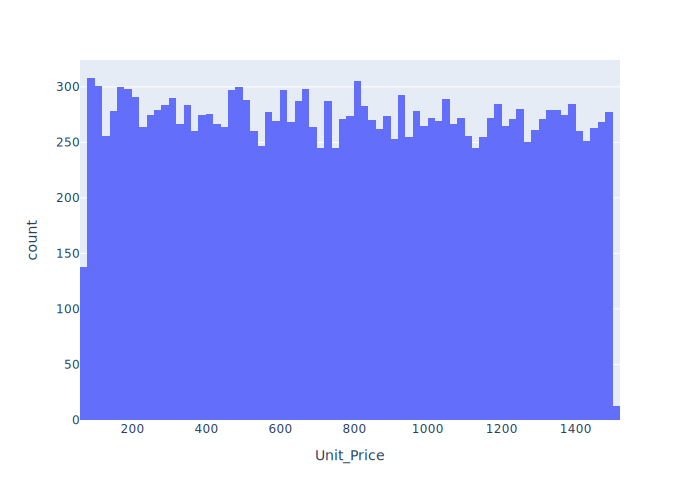

In [24]:
px.histogram(df, x= "Unit_Price" )

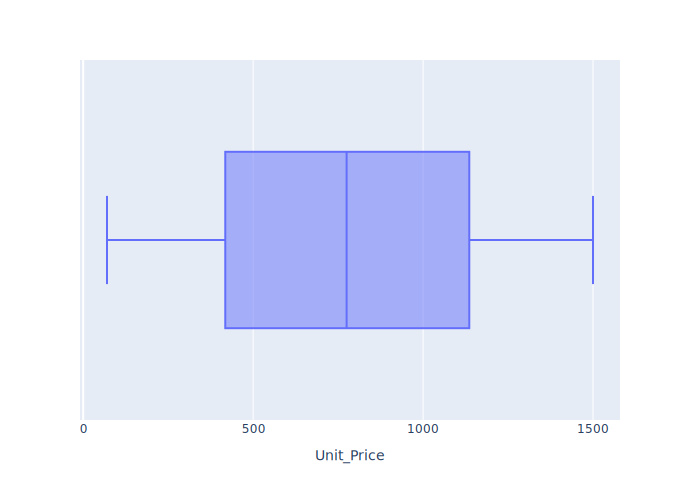

In [25]:
px.box(df, x= "Unit_Price" )

## Amount

In [26]:
df[["Quantity", "Unit_Price", "Amount", "Tax", "Delivery_chrgs" ] ].head(10)

,Quantity,Unit_Price,Amount,Tax,Delivery_chrgs
0,3,359,1795,188.475,90.0
1,5,1129,5645,592.725,250.0
2,4,1327,6635,696.675,NaN
3,5,1325,6625,695.625,NaN
4,3,1237,6185,649.425,NaN
5,5,837,837,87.885,50.0
6,4,931,2793,293.265,NaN
7,2,1211,3633,381.465,200.0
8,1,1497,4491,471.555,200.0
9,5,1008,2016,211.680,90.0


### During data validation, we discovered inconsistencies in the Amount column. For example, in the first row:

**Quantity = 3**
**Unit_Price = 359**
**Expected Amount = 3 × 359 = 1077**

**However, the existing value in the Amount column was 1795, which is incorrect.**

**To resolve this issue and ensure data accuracy, we recalculated the Amount BY multibly Quantity * Unit_Price  deleted the original and named by Total_Price**

In [27]:
# drop column
df.drop("Amount", axis= 1, inplace= True)

In [28]:
# recalculated column and named by Total_Price
df['Price'] = df['Quantity'] * df['Unit_Price']

In [29]:
df.Price.describe()

count    19597.000000
mean      2397.469664
std       1795.267407
min         70.000000
25%        948.000000
50%       1936.000000
75%       3534.000000
max       7500.000000
Name: Price, dtype: float64

In [30]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Tax', 'Delivery_chrgs', 'Payment_mode', 'Store_type',
       'Reviews', 'Income', 'city', 'Return', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type', 'Price'],
      dtype='object')

In [31]:
# Rearrange columns
df = df[['Month', 'product_category', 'Product_Subcategory', 'Quantity',
         'Unit_Price', 'Price', 'Tax', 'Delivery_chrgs' ,'Payment_mode', 'Store_type', 'Reviews',
         'Income', 'city', 'DOB', 'Gender', 'Marital_status', 'Education_Level',
         'Profession_Type', 'Return']]

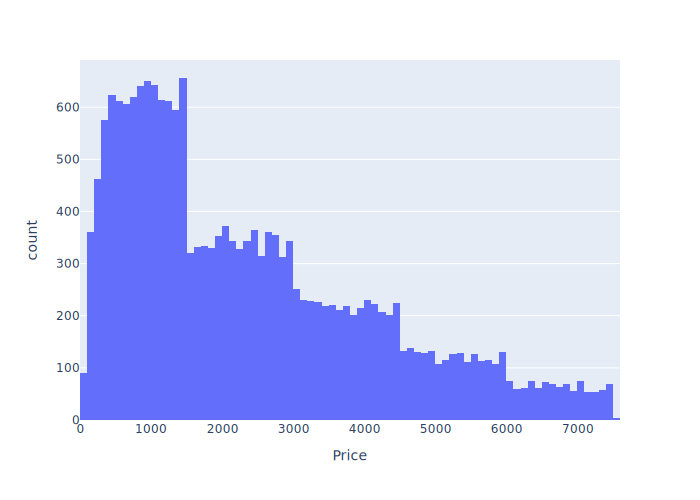

In [32]:
px.histogram(df, x= "Price" )

In [33]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Delivery_chrgs', 'Payment_mode',
       'Store_type', 'Reviews', 'Income', 'city', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type', 'Return'],
      dtype='object')

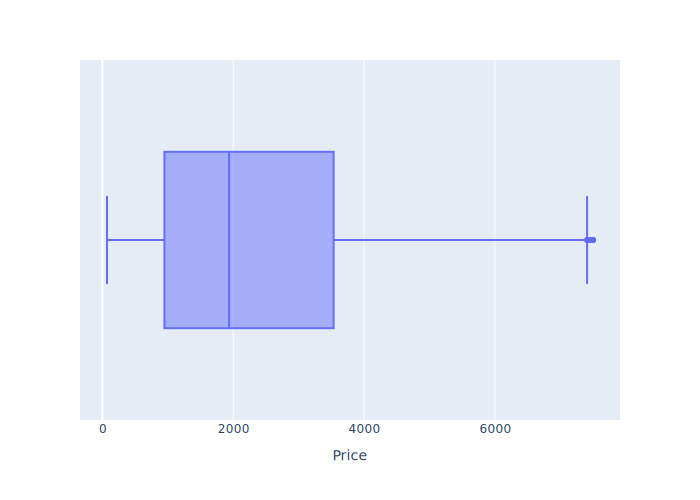

In [34]:
px.box(df, x= "Price" )

In [35]:
from datasist.structdata import detect_outliers

outliers_indices = detect_outliers(df, 0 , ["Price"])

len(outliers_indices)

62

### Tax

In [36]:
df.Tax.describe()

count    19597.000000
mean       241.722141
std        182.975767
min          7.350000
25%         96.075000
50%        191.730000
75%        351.540000
max        787.500000
Name: Tax, dtype: float64

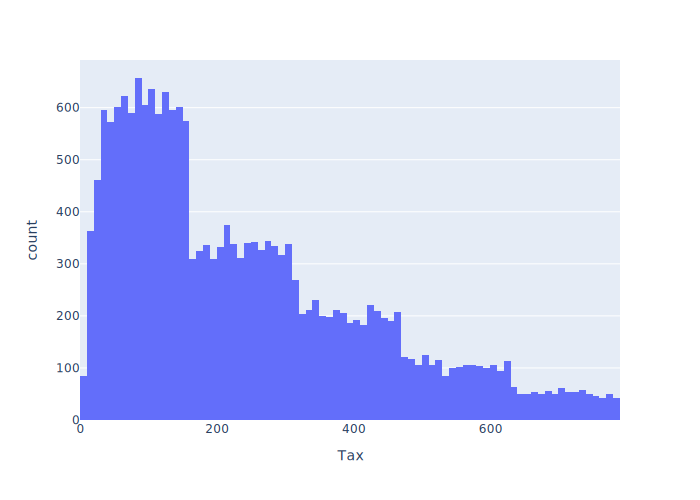

In [37]:
px.histogram(df, x= "Tax" )

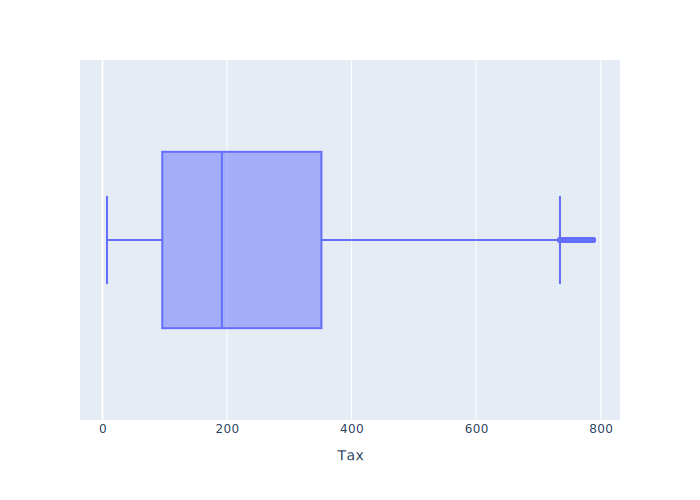

In [38]:
px.box(df, x= "Tax" )

In [39]:
from datasist.structdata import detect_outliers

outliers_indices = detect_outliers(df, 0 , ["Tax"])

len(outliers_indices)

265

In [40]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Delivery_chrgs', 'Payment_mode',
       'Store_type', 'Reviews', 'Income', 'city', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type', 'Return'],
      dtype='object')

### Delivery_charges (will drop column becouse has very big missing )

In [41]:
df.Delivery_chrgs.isna().sum()

8890

In [ ]:
df.drop("Delivery_chrgs", inplace= True, axis= 1)
df.reset_index(inplace= True, drop= True)

### Payment_mode

In [44]:
df.Payment_mode.unique()

array(['Mobile Payments', 'Credit Card', 'Debit Card', 'Cash'],
      dtype=object)

In [45]:
df.Payment_mode.value_counts()

Payment_mode
Mobile Payments    8191
Credit Card        4683
Debit Card         4677
Cash               2046
Name: count, dtype: int64

## Store_type

In [46]:
df.Store_type.unique()

array(['e-Shop', 'TeleShop', 'MBR', 'Flagship store'], dtype=object)

In [47]:
df.Store_type.value_counts()

Store_type
e-Shop            8014
MBR               3886
TeleShop          3872
Flagship store    3825
Name: count, dtype: int64

## Reviews

In [48]:
df.Reviews.unique()

array([ 1.,  4.,  2.,  5.,  3., nan])

In [49]:
df.Reviews.value_counts()

Reviews
5.0    9537
4.0    4696
1.0    2491
2.0    1542
3.0    1280
Name: count, dtype: int64

In [50]:
df['Reviews'].isnull().sum()

51

In [51]:
# remave nulll in column because it dosn't make sense to impute Reviews
df = df.dropna(subset=['Reviews'])
df['Reviews'].isnull().sum()

0

In [52]:
df["Reviews"].value_counts()

Reviews
5.0    9537
4.0    4696
1.0    2491
2.0    1542
3.0    1280
Name: count, dtype: int64

In [53]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'DOB', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

## Income

In [54]:
df.Income.describe()

count     19504.000000
mean      70516.888074
std       37418.384648
min        7157.000000
25%       37950.000000
50%       69293.000000
75%       99534.000000
max      159984.000000
Name: Income, dtype: float64

In [55]:
df['Income'].isnull().sum()

42

In [56]:
df = df.dropna(subset=['Income'])
df['Income'].isnull().sum()

0

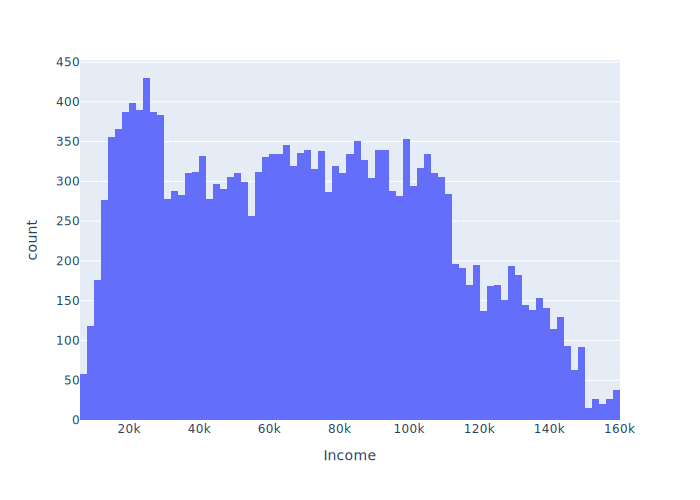

In [57]:
px.histogram(df, x= "Income" )

## Return

In [58]:
df.Return.unique()

array([ True, False])

In [59]:
df.Return.value_counts()

Return
False    17457
True      2047
Name: count, dtype: int64

In [60]:
df["Return"] = df["Return"].map({False: 0, True: 1})

In [61]:
df.Return.value_counts()

Return
0    17457
1     2047
Name: count, dtype: int64

### **Target is imbalanced and will be handled in the preprocessing pipeline.**

## DOB

In [62]:
df.DOB.unique()

<DatetimeArray>
['1985-12-31 00:00:00', '1985-12-29 00:00:00', '1985-12-27 00:00:00',
 '1985-12-26 00:00:00', '1985-12-24 00:00:00', '1985-12-22 00:00:00',
 '1985-12-20 00:00:00', '1985-12-19 00:00:00', '1985-12-18 00:00:00',
 '1985-12-17 00:00:00',
 ...
 '1964-01-29 00:00:00', '1964-01-28 00:00:00', '1964-01-22 00:00:00',
 '1964-01-11 00:00:00', '1964-01-10 00:00:00', '1964-01-06 00:00:00',
 '1964-01-05 00:00:00', '1964-01-04 00:00:00', '1964-01-03 00:00:00',
 '1964-01-02 00:00:00']
Length: 3996, dtype: datetime64[ns]

In [63]:
# I deleted the column because it will not important in prediction.
df.drop("DOB", inplace= True, axis= 1 )
df.reset_index(inplace= True, drop= True)

## Gender

In [64]:
df.Gender.unique()

array(['M', 'F'], dtype=object)

In [65]:
df.Gender.value_counts()

Gender
M    12028
F     7476
Name: count, dtype: int64

## Marital_status

In [66]:
df.Marital_status.unique()

array([0, 1])

In [67]:
df.Marital_status.value_counts()

Marital_status
1    10316
0     9188
Name: count, dtype: int64

## Education_Level

In [68]:
df.Education_Level.unique()

array(['PhD', 'Master', 'Basic', 'Others', 'Graduation'], dtype=object)

## Profession_Type

In [69]:
df.Profession_Type.unique()

array(['Others', 'Salaried', 'Self Employed'], dtype=object)

In [70]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

In [71]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

# baivariate analysis

## Does Payment_mode affect the return rate?

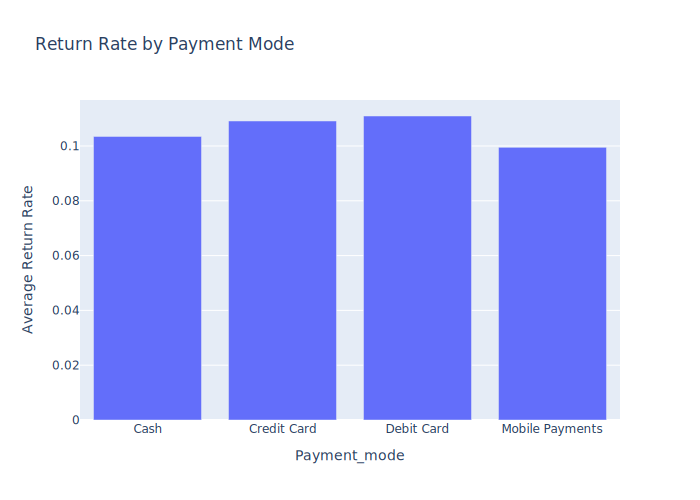

In [72]:
return_by_payment = df.groupby('Payment_mode')['Return'].mean().reset_index()

fig = px.bar(return_by_payment, x='Payment_mode', y='Return',
             title='Return Rate by Payment Mode',
             labels={'Return': 'Average Return Rate'})
fig.show()


### Insight Summary:

#### - **The effect of payment mode on returns seems weak because the differences are small (only about 2% between Credit Card and others).**

## Does the Store_type influence returns?

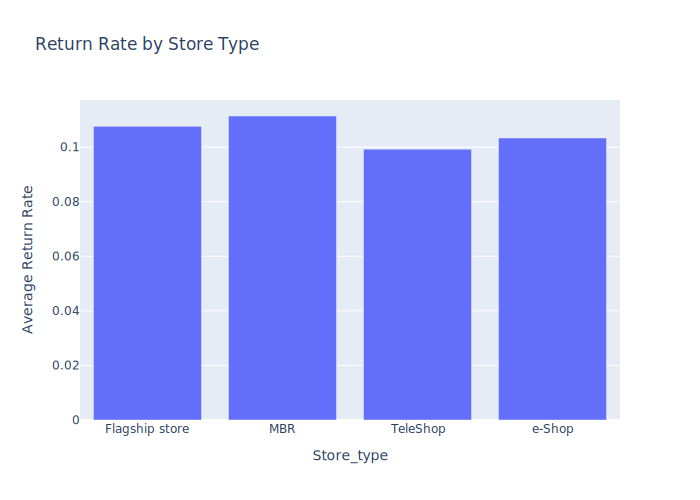

In [73]:
return_by_store = df.groupby('Store_type')['Return'].mean().reset_index()

fig = px.bar(return_by_store, x='Store_type', y='Return',
             title='Return Rate by Store Type',
             labels={'Return': 'Average Return Rate'})
fig.show()


In [74]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

## Does Income level influence return behavior?

In [75]:
df.Income.describe()

count     19504.000000
mean      70516.888074
std       37418.384648
min        7157.000000
25%       37950.000000
50%       69293.000000
75%       99534.000000
max      159984.000000
Name: Income, dtype: float64

In [76]:
# Create income category bins
bins = [0, 38000, 69000, 99000, df['Income'].max()]
labels = ['Low', 'Medium', 'High', 'Very High']

df['Income_Category'] = pd.cut(df['Income'], bins= bins, labels= labels, include_lowest=True)


df['Income_Category'].value_counts()

Income_Category
Very High    4972
Low          4885
High         4828
Medium       4819
Name: count, dtype: int64

/var/folders/0f/sg0d5c153zv11896v810g2_80000gn/T/ipykernel_10303/3241298616.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



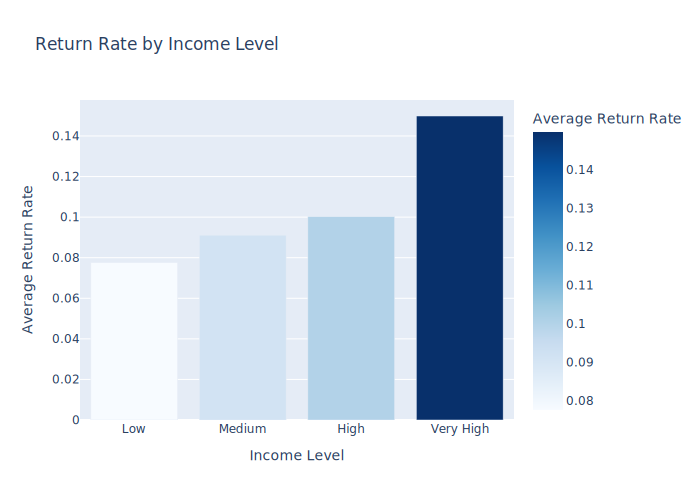

,Income_Category,Return
0,Low,0.077584
1,Medium,0.091098
2,High,0.100249
3,Very High,0.149839


In [77]:
return_by_income = df.groupby('Income_Category')['Return'].mean().reset_index()

fig = px.bar(return_by_income,
             x='Income_Category',
             y='Return',
             title='Return Rate by Income Level',
             labels={'Return': 'Average Return Rate', 'Income_Category': 'Income Level'},

             color='Return',
             color_continuous_scale='Blues')
fig.show()

return_by_income

### - Insight Summary:

- 1- **Very High income level has the highest return rate at 0.14 (14% returned), much higher than the others**

- 2- **The effect of income on returns is strong because Very High income people return a lot more than others.**


### - Recommendation Summary:

- **1- Focus on why Very High income customers return items—maybe they buy expensive things and change their minds.**

- **2- Check if product quality or store service needs improvement for high-income shoppers**

## What is Return Rate of products in each Category?




In [78]:
# Calculate average return rate by product category and subcategory
return_by_category = (
    df.groupby(['product_category', 'Product_Subcategory'])['Return']
      .mean()
      .reset_index()
      .sort_values('Return', ascending=False)
)

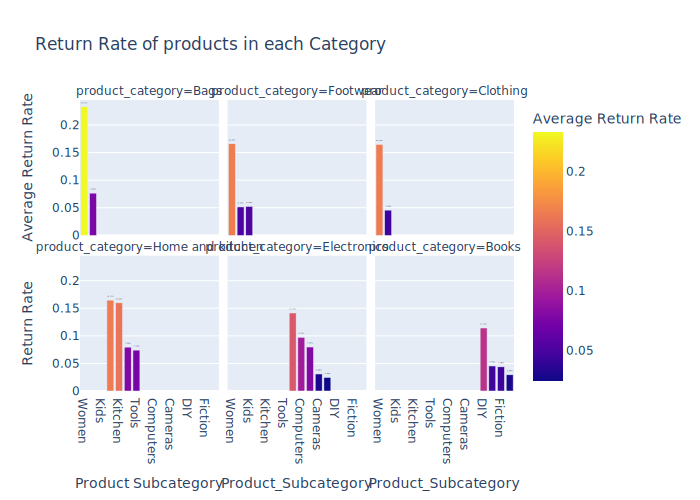

,product_category,Product_Subcategory,Return
1,Bags,Women,0.233103
15,Footwear,Women,0.165912
7,Clothing,Women,0.164884
17,Home and kitchen,Furnishing,0.164731
18,Home and kitchen,Kitchen,0.159868
11,Electronics,Mobiles,0.141447
3,Books,DIY,0.114241
10,Electronics,Computers,0.097264
12,Electronics,Personal Appliances,0.079734
16,Home and kitchen,Bath,0.079532


In [79]:
# Faceted bar chart
fig = px.bar(
    return_by_category,
    x='Product_Subcategory',
    y='Return',
    color='Return',
    facet_col='product_category',
    facet_col_wrap=3,  # Adjust number of columns shown per row
    title='Return Rate of products in each Category',
    labels={'Return': 'Average Return Rate'},
    text='Return'
)

# Beautify layout
fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.update_layout(
    xaxis_title='Product Subcategory',
    yaxis_title='Return Rate',
    height=800,
    showlegend=False
)

fig.show()
return_by_category

### - Insight Summary:

- **1- In the Bags, Footwear, and Clothing categories, Women’s products have a high return rate above 17%, much higher than Men’s products, suggesting a specific issue with women’s items.**

- **2- In the Home and Kitchen category, Kitchen and Furnishing subcategories show significant returns at 15-16%, indicating potential problems in these areas.**

- **3- n the Electronics category, Mobiles have a notable return rate of 14%, pointing to possible quality or usability concerns.**

- **4-In the Books category, DIY stands out with a 12% return rate, higher than other subcategories, suggesting an area needing attention.**

- **5-The effect of gender and subcategory on returns is strong, with women’s products and specific subcategories like Kitchen, Furnishing, Mobiles, and DIY driving higher return rates.**

### - Recommendation Summary:

- **1- For Bags, Footwear, and Clothing, investigate why Women’s products exceed 17% returns—check for sizing issues, fit problems, or quality defects—and improve product design or provide better fitting guides**

- **2- For Electronics, address Mobiles’ 14% return rate with better quality control, improved warranties, or customer support for technical issues.**

- **3- Collect customer feedback during the trial month to understand why they are returning products (e.g., wrong size or poor quality) and
Use the results to improve the products.**

## How does Reviews (customer satisfaction) relate to Return ?

In [80]:
df.Reviews.describe()

count    19504.000000
mean         3.882639
std          1.414655
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Reviews, dtype: float64

In [81]:
def categorize_review(x):
    if x <= 2:
        return 'Low'
    elif x == 3:
        return 'Medium'
    else:
        return 'High'

df['Review_Level'] = df['Reviews'].apply(categorize_review)

df.Review_Level.value_counts()

Review_Level
High      14204
Low        4021
Medium     1279
Name: count, dtype: int64

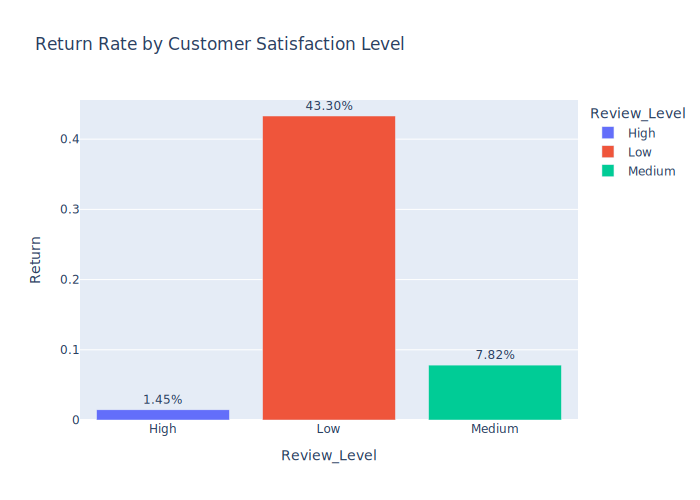

In [82]:
# Calculate return rate by review level
review_return = df.groupby('Review_Level')['Return'].mean().reset_index()

# Plot interactive chart
fig = px.bar(
    review_return,
    x='Review_Level',
    y='Return',
    color='Review_Level',
    title='Return Rate by Customer Satisfaction Level',
    text='Return',
)

fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.show()


### - Insight Summary:

-  **1- Low satisfaction level has the highest return rate at 0.43 (43% returned), much higher than the average.**

-  **1- The effect of satisfaction level on returns is strong because low satisfaction leads to a lot more returns than high or medium..**


### - Recommendation Summary:

- **1- Focus on improving satisfaction for customers with low reviews to reduce returns.**


## **Does the tax amount (Low / Medium / High) influence whether a product is returned?**

In [83]:
df.Tax.describe()

count    19504.000000
mean       241.235454
std        182.887380
min          7.350000
25%         95.760000
50%        190.785000
75%        349.965000
max        787.500000
Name: Tax, dtype: float64

In [84]:
# Convert the tax column into three categories to see the effect and determine if one category is larger than another

def map_tax(x):
    if x <= 95.76:
        return "Low"
    elif x <= 349.97:
        return "Medium"
    else:
        return "High"

df["Tax_Level"] = df["Tax"].apply(map_tax)

In [85]:
df.Tax_Level.value_counts()

Tax_Level
Medium    9750
Low       4880
High      4874
Name: count, dtype: int64

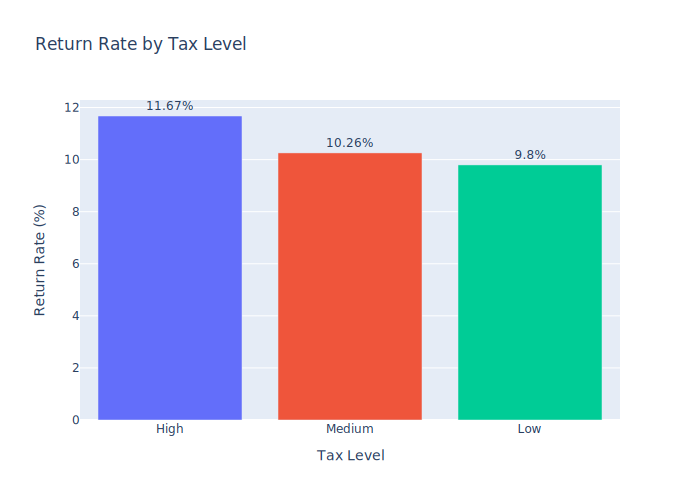

In [86]:
# Calculate mean return rate per tax level
tax_return = df.groupby("Tax_Level")["Return"].mean().reset_index().sort_values("Return", ascending=False)

# Convert to percentage
tax_return["Return"] = tax_return["Return"] * 100

# Plot
fig = px.bar(
    tax_return,
    x= "Tax_Level",
    y= "Return",
    color="Tax_Level",
    text= tax_return["Return"].round(2).astype(str) + '%',
    title= "Return Rate by Tax Level",
    labels= {"Tax_Level": "Tax Level", "Return": "Return Rate (%)"}
)

fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

# Multivariate analysis

## What is the combined effect of Customer Satisfaction Level on returns for Women’s Clothing and Footwear?

#### **- To see if reviews affect returns of women's products that have a high percentage of returns.**

In [87]:
df[['product_category', 'Product_Subcategory']]

,product_category,Product_Subcategory
0,Books,Fiction
1,Clothing,Women
2,Home and kitchen,Bath
3,Footwear,Mens
4,Clothing,Women
...,...,...
19499,Electronics,Audio and video
19500,Bags,Mens
19501,Footwear,Women
19502,Electronics,Mobiles


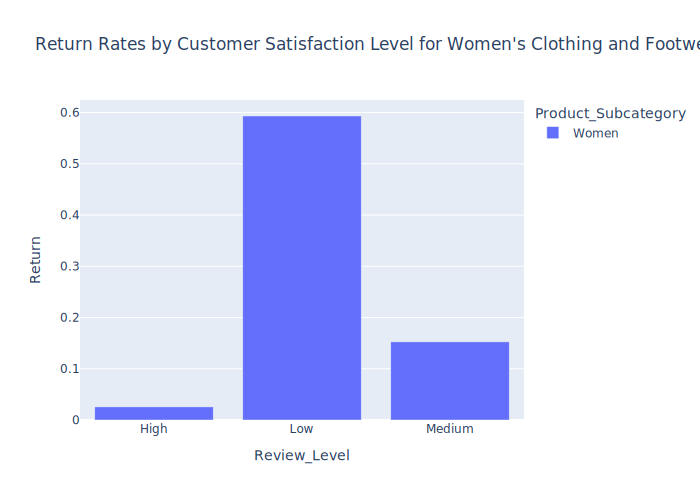

,Product_Subcategory,Review_Level,Return
0,Women,High,0.025557
1,Women,Low,0.593338
2,Women,Medium,0.152493


In [88]:
# Filter for Women’s products
df_women = df[df["Product_Subcategory"] == "Women"]

# Compute return rates by Satisfaction Level and Subcategory
return_analysis = (
    df_women.groupby(["Product_Subcategory", "Review_Level"])["Return"]
    .mean()
    .reset_index()
    .sort_values(by=["Product_Subcategory", "Review_Level"])
)

# Visualize
import plotly.express as px

fig = px.bar(
    return_analysis,
    x="Review_Level",
    y="Return",
    color="Product_Subcategory",
    barmode="group",
    title="Return Rates by Customer Satisfaction Level for Women's Clothing and Footwear",
    labels={"Returned": "Return Rate"},
)
fig.show()

return_analysis


-

## How does Reviews (customer satisfaction) relate to Return for each category

In [89]:
review_return = (
    df.groupby(["product_category", "Reviews"])["Return"]
    .mean()
    .reset_index()
    .sort_values(by=["product_category", "Reviews"])
)

review_return

,product_category,Reviews,Return
0,Bags,1.0,0.669811
1,Bags,2.0,0.352381
2,Bags,3.0,0.125749
3,Bags,4.0,0.045000
4,Bags,5.0,0.020344
5,Books,1.0,0.398406
6,Books,2.0,0.156250
7,Books,3.0,0.020270
8,Books,4.0,0.011706
9,Books,5.0,0.006344


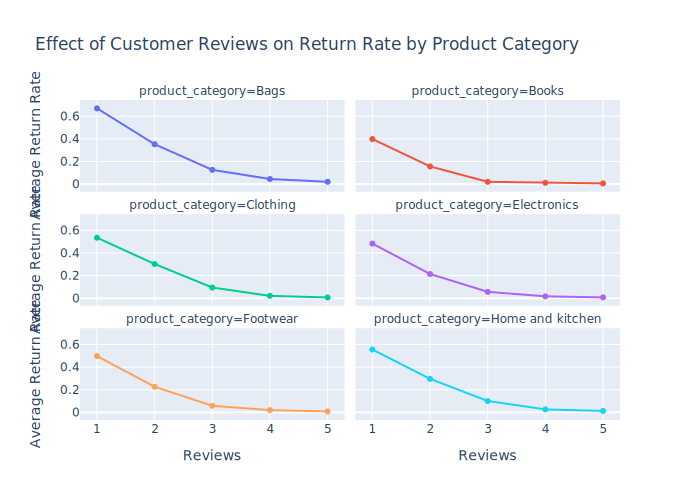

In [90]:
fig = px.line(
    review_return,
    x="Reviews",
    y="Return",
    color="product_category",
    facet_col="product_category",
    facet_col_wrap=2,  # adjust number of columns shown in the grid
    markers=True,
    title="Effect of Customer Reviews on Return Rate by Product Category",
    labels={"Return": "Average Return Rate", "Review": "Customer Review (Satisfaction)"},
)

fig.update_traces(line=dict(width=2))
fig.update_layout(showlegend=False)
fig.show()


### - Insight Summary:

-  **The relationship between Reviews and Return is strong across categories, especially for Women’s products, where low satisfaction significantly boosts returns.**


### - Recommendation Summary:

- **Focus on addressing the 59% return rate for Women’s Clothing and Footwear under low satisfaction by improving product quality or fit.**


## How do Income Level and Product Category interact to affect return rates?

#### **- Combining them helps identify segments driving high return rates (e.g. wealthy customers returning specific products).**

#### **- Identify which income ategory combinations have the highest or lowest return rates.**

In [91]:
df['Income_Category'].value_counts()

Income_Category
Very High    4972
Low          4885
High         4828
Medium       4819
Name: count, dtype: int64

In [92]:
#  average return rate by category and income
income_category_return = (
    df.groupby(["Income_Category", "product_category"])["Return"]
    .mean()
    .reset_index()
)


/var/folders/0f/sg0d5c153zv11896v810g2_80000gn/T/ipykernel_10303/225613887.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



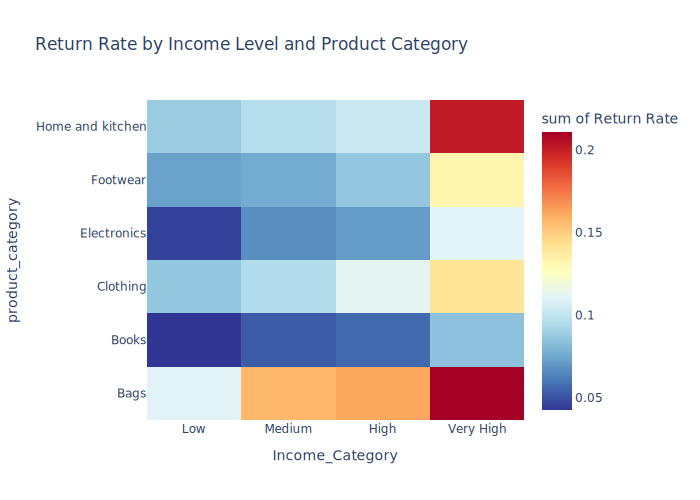

,Income_Category,product_category,Return
0,Low,Bags,0.110260
1,Low,Books,0.042589
2,Low,Clothing,0.085793
3,Low,Electronics,0.045455
4,Low,Footwear,0.072827
5,Low,Home and kitchen,0.087838
6,Medium,Bags,0.156986
7,Medium,Books,0.052356
8,Medium,Clothing,0.094977
9,Medium,Electronics,0.066998


In [93]:
# Plot heatmap
fig = px.density_heatmap(
    income_category_return,
    x="Income_Category",
    y="product_category",
    z="Return",
    color_continuous_scale="RdYlBu_r",
    title="Return Rate by Income Level and Product Category",
    labels={"Return": "Return Rate"}
)

fig.show()
income_category_return


### - Insight Summary:

-  **1- Very High income customers drive the highest return rates, particularly for Bags (up to 20%) and Home and Kitchen (18-20%), indicating their significant influence on returns.**

-  **2- Bags show elevated returns across Medium and Very High income levels, with the peak at 20% for Very High income, suggesting sensitivity to product quality or expectations.**

-  **3- Home and Kitchen returns surge to 18-20% for Very High income buyers, reflecting their critical role in this category.**

###  **- The data highlights that Very High income customers, as a sensitive and important category, are a key factor in driving returns, especially for Bags and Home and Kitchen.**


### - Recommendation Summary:

- **1-Recognize Very High income customers as an important segment and develop strategies to retain them, such as exclusive offers or better return handling.**


## What is Return Rate by Tax Level for each Product Subcategory ?

In [94]:
df.Tax_Level.value_counts()

Tax_Level
Medium    9750
Low       4880
High      4874
Name: count, dtype: int64

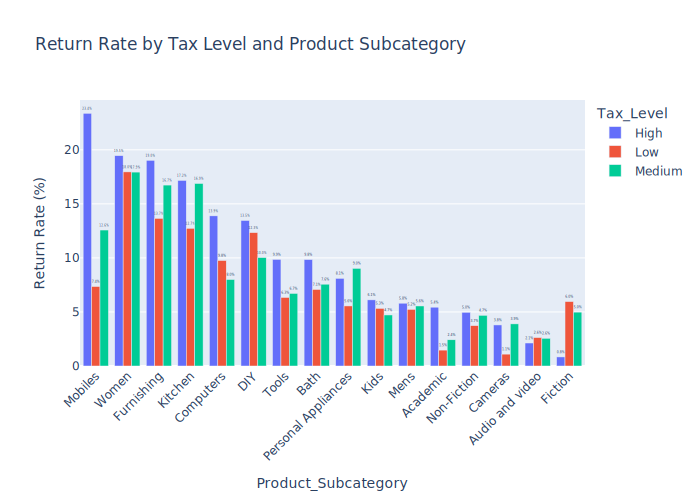

In [95]:
tax_sub_return = (
    df.groupby(["Tax_Level", "Product_Subcategory"])["Return"]
    .mean()
    .reset_index()
    .sort_values("Return", ascending=False)
)

# Convert Return rate to %
tax_sub_return["Return"] = tax_sub_return["Return"] * 100

# Plot as grouped bar chart
fig = px.bar(
    tax_sub_return,
    x="Product_Subcategory",
    y="Return",
    color="Tax_Level",
    barmode="group",
    text=tax_sub_return["Return"].round(1).astype(str) + '%',
    title="Return Rate by Tax Level and Product Subcategory",
    labels={"Return": "Return Rate (%)"}
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

### - Insight Summary:

-  **1- Mobiles under the highest tax level show the highest return rate by 24% for both, indicating a strong link between high tax and returns for this subcategory**

-  **2- Other subcategories like Women (19-20%) and Furnishing/Kitchen (15-19%) also have elevated returns under high tax**

-  **3- Women (19-20%) across all tax levels ، they have very big problem**

#### **- High tax level drives higher returns, especially for Mobiles and Women**

### - Recommendation Summary:

- **1-Focus on Mobiles with a 24% return rate under high tax—investigate quality issues or perceived value and consider tax relief or discounts.**

- **2-Launch a pilot with tax adjustments or enhanced warranties for Mobiles to reduce the 24% return rate.**




________________________________________________________________________________

## **Final Recommendations**



### Action Plan to Reduce Returns



-  **1-Focus on Women’s Bags: Fix the 59% return rate for low satisfaction by improving quality and fit. Add clear size guides and let customers try before buying.**



-  **2-Improve Women’s Clothing and Footwear: Cut the 55% and 52% returns for low satisfaction with better designs and easy return options. Offer fit advice in stores.**



-  **3-Boost Women’s Home and Kitchen: Lower the 50% return rate for low satisfaction by checking product quality and giving simple use instructions.**



-  **4-Help with Mobiles: Reduce the 24% return rate for low satisfaction in Electronics by offering strong warranties and quick tech support.**



-  **4-Target High Tax and Income Issues: For items like Mobiles (24% at high tax) and Bags (20% for Very High income), test lower taxes or discounts to keep customers happy.**



-  **5-Use Happy Customers: Learn from the 3% return rate with high satisfaction—share good designs and service tips across all products.**



-  **6-Start a Big Test: Run a pilot program with fit checks, surveys, and better support for low-satisfaction customers, especially for Women’s products and high-tax items, to find and fix problems fast.**



-  **7-Collect Data on Returned Products: Gather info from all returned items in every category using: surveys, logs, or feedback forms. Common causes include sizing/fit issues, damaged/defective products, unmet expectations, and shipping damage. Use this data to fix problems, such as better size guides for clothing/bags, stronger packaging for electronics/home items, and clear descriptions for books.**

In [96]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return', 'Income_Category', 'Review_Level',
       'Tax_Level'],
      dtype='object')

In [97]:
# drop column we create in analysis that will be not needed in ather steps.
df.drop([ 'Tax_Level', 'Review_Level', 'Income_Category',], inplace= True, axis= 1)

In [98]:
df.reset_index(drop= True, inplace= True)

# Feature engineering

In [99]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

### create derived columns to help model learn better.

In [100]:
df['total_price'] = df['Price'] + df['Tax']

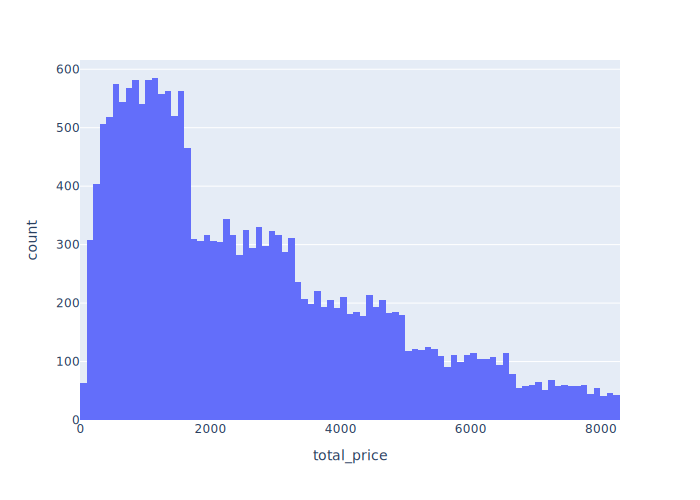

In [101]:
px.histogram(df, x= "total_price")

In [102]:
df['tax_ratio'] = df['Tax'] / (df['Price'] + 1)

# Choose best and importan Feature

## this step will Filter features by choose important ones by (correlation and Extraclassifier )

## 1-corrolation

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19504 entries, 0 to 19503
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month                19504 non-null  object 
 1   product_category     19504 non-null  object 
 2   Product_Subcategory  19504 non-null  object 
 3   Quantity             19504 non-null  int64  
 4   Unit_Price           19504 non-null  int64  
 5   Price                19504 non-null  int64  
 6   Tax                  19504 non-null  float64
 7   Payment_mode         19504 non-null  object 
 8   Store_type           19504 non-null  object 
 9   Reviews              19504 non-null  float64
 10  Income               19504 non-null  float64
 11  city                 19504 non-null  object 
 12  Gender               19504 non-null  object 
 13  Marital_status       19504 non-null  int64  
 14  Education_Level      19504 non-null  object 
 15  Profession_Type      19504 non-null 

In [104]:
df_Cat = df.select_dtypes(include= "number")
df_Cat.columns

Index(['Quantity', 'Unit_Price', 'Price', 'Tax', 'Reviews', 'Income',
       'Marital_status', 'Return', 'total_price', 'tax_ratio'],
      dtype='object')

In [105]:
df_Cat = df.select_dtypes(include= "number")
corr = df_Cat.corr()['Return'].sort_values(ascending=False)
print(corr)

Return            1.000000
Quantity          0.264764
Price             0.181667
total_price       0.168094
Income            0.096515
Tax               0.025561
Unit_Price        0.016190
Marital_status    0.004795
tax_ratio        -0.165521
Reviews          -0.541104
Name: Return, dtype: float64


In [106]:
corr_matrix = df_Cat.corr()

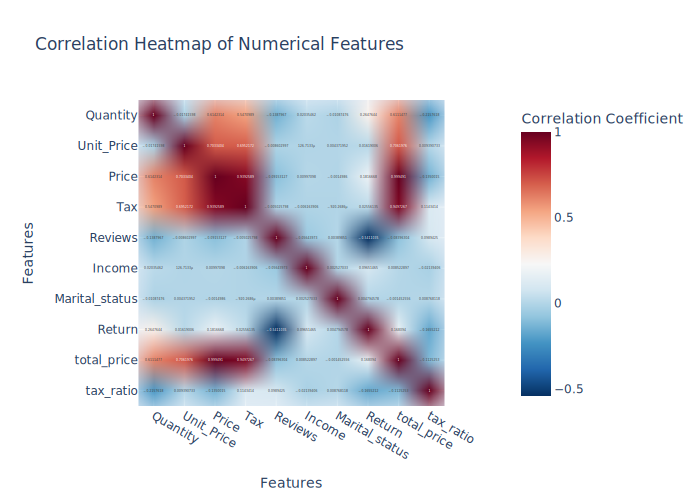

In [107]:
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation Heatmap of Numerical Features',
    labels=dict(color='Correlation Coefficient')
)

fig.update_layout(
    width=1500,
    height=900,
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

In [108]:
df_Cat = df.select_dtypes(include="object")

for col in df_Cat.columns :
    print(f"Column {col} has {df_Cat[col].nunique()} values")

Column Month has 12 values
Column product_category has 6 values
Column Product_Subcategory has 16 values
Column Payment_mode has 4 values
Column Store_type has 4 values
Column city has 10 values
Column Gender has 2 values
Column Education_Level has 5 values
Column Profession_Type has 3 values


In [109]:
df.select_dtypes(include="object").columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Payment_mode',
       'Store_type', 'city', 'Gender', 'Education_Level', 'Profession_Type'],
      dtype='object')

In [110]:
df.select_dtypes(include=["number"]).columns

Index(['Quantity', 'Unit_Price', 'Price', 'Tax', 'Reviews', 'Income',
       'Marital_status', 'Return', 'total_price', 'tax_ratio'],
      dtype='object')

# 2-ExtraTreesClassifier

#### - Feature Importance Analysis by ExtraTreesClassifier -

- This script prepares feature and evaluates feature importance
using an ExtraTreesClassifier.


Why ExtraTrees:
----------------
ExtraTrees (Extremely Randomized Trees) is a tree-based ensemble method that:
- Handles both numerical and categorical inputs after encoding.
- Is resistant to noise and outliers.
- Provides reliable estimates of feature importance, guiding feature selection
  and model refinement.

Key Steps:
------------

1. Encode categorical features:
  
2. Combine encoded categorical and numeric usage features.

3. Train ExtraTreesClassifier:
   - Robust to outliers, no scaling needed.
   - Provides reliable feature importance.

4. Extract and sort feature importance to identify key drivers of return.


## ------------------------- This explain coming code ----------------------------------- ##

In [111]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier

cat_cols = [

   'Month', 'product_category', 'Product_Subcategory', 'Payment_mode',
       'Store_type', 'city', 'Gender', 'Education_Level', 'Profession_Type',
]

num_cols = ['Quantity', 'Unit_Price', 'Tax', 'Reviews', 'Income',
       'Marital_status', 'Price',  "total_price", "tax_ratio"]

df_encoded = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


X = df_encoded[cat_cols + num_cols]
y = df_encoded['Return']

In [112]:
# Fit ExtraTreesClassifier

model = ExtraTreesClassifier(random_state=42)
model.fit(X, y)

#  Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

#  Show top features
importances_sorted

tax_ratio              0.369680
Reviews                0.230011
Quantity               0.067953
Tax                    0.055899
Price                  0.038334
total_price            0.030570
Unit_Price             0.024145
Product_Subcategory    0.023365
Income                 0.022222
Month                  0.021806
Payment_mode           0.021619
city                   0.017285
product_category       0.016111
Education_Level        0.015172
Store_type             0.013786
Profession_Type        0.012997
Marital_status         0.009782
Gender                 0.009264
dtype: float64

In [113]:
# # Drop low columns importances
df.drop(["Gender", "Marital_status", "Profession_Type", "Education_Level", "Store_type", "Month" ], inplace= True, axis= 1)

# Modling

In [114]:
df_Cat = df.select_dtypes(include="object")

for col in df_Cat.columns :
    print(f"Column {col} has {df_Cat[col].nunique()} values")

Column product_category has 6 values
Column Product_Subcategory has 16 values
Column Payment_mode has 4 values
Column city has 10 values


In [115]:
df.describe()

,Quantity,Unit_Price,Price,Tax,Reviews,Income,Return,total_price,tax_ratio
count,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000
mean,3.097724,776.168222,2393.920991,241.235454,3.882639,70516.888074,0.104953,2635.156445,0.103398
std,1.446259,414.249426,1795.395383,182.887380,1.414655,37418.384648,0.306500,1968.175145,0.026386
min,1.000000,70.000000,70.000000,7.350000,1.000000,7157.000000,0.000000,77.350000,0.020943
25%,2.000000,417.000000,945.000000,95.760000,3.000000,37950.000000,0.000000,1046.158750,0.104863
50%,3.000000,773.000000,1930.000000,190.785000,4.000000,69293.000000,0.000000,2126.020000,0.104937
75%,4.000000,1135.000000,3522.000000,349.965000,5.000000,99534.000000,0.000000,3875.235000,0.104968
max,5.000000,1500.000000,7500.000000,787.500000,5.000000,159984.000000,1.000000,8287.500000,0.524641


In [116]:
Binary_encoding = ["Product_Subcategory", "city" ]

Label_encoding = ["product_category", "Payment_mode" ]

num_columns = ['Unit_Price', 'Price', 'Tax', 'Income', "tax_ratio", "total_price"]

In [ ]:
# pip install scikit-learn==1.3.2 category-encoders==2.6.3 

In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder , RobustScaler , StandardScaler , OrdinalEncoder
from category_encoders.binary import BinaryEncoder

from sklearn.model_selection import GridSearchCV, KFold, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, accuracy_score

from sklearn.linear_model import LogisticRegression


In [119]:
''''
Preprocessing Pipeline:
- cat: Apply Binary and Label encoding to categorical features 
- num_scaling: Apply RobustScaler to numeric features 
  → using RobustScaler becouse it handles outliers
- remainder='passthrough': keep any other columns unchanged.

'''

Transformation = ColumnTransformer(
    transformers=[
        ("Label_encoding", OneHotEncoder(sparse_output=False, drop="first"), Label_encoding),
        ("BE", BinaryEncoder(), Binary_encoding),
        ("num", RobustScaler(), num_columns)
    ],
    remainder="passthrough"
)

In [125]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## for test pipline work or not

#### **Model Evaluation with Cross-Validation (testing to see every thing work or not)**

In [126]:
steps = [
    ("Transform", Transformation),
    ("LR", LogisticRegression())
]

pipeline = Pipeline(steps=steps)

In [127]:
df.columns

Index(['product_category', 'Product_Subcategory', 'Quantity', 'Unit_Price',
       'Price', 'Tax', 'Payment_mode', 'Reviews', 'Income', 'city', 'Return',
       'total_price', 'tax_ratio'],
      dtype='object')

In [128]:
x = df.drop("Return", axis = 1 )
y = df["Return"]

In [129]:
kf = KFold(n_splits= 5, shuffle= True, random_state= 20 )
result = cross_validate(pipeline , x ,y , cv = kf , scoring="accuracy" , return_train_score= True)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

In [130]:
result["train_score"].mean()

0.9469724286945981

In [131]:
result["test_score"].mean()

0.9466263877112377

In [132]:
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate, KFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline



from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB , MultinomialNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

## try all models and chose the best one to do tunung and deploy

In [133]:
models = [
      ("DT", DecisionTreeClassifier()),
      ("RF", RandomForestClassifier()),
      ("XGB", XGBClassifier())
]

In [134]:
y.value_counts()

Return
0    17457
1     2047
Name: count, dtype: int64

In [142]:
#  This code handles the minority class using SMOTE tomec, After applying ,
# it displays the resulting number of instances in both classes after aplying of 2 class how will be to choose best number and put in pipeline .

from collections import Counter

print("Before:", Counter(y))
X_res, y_res = SMOTETomek(smote=SMOTE(sampling_strategy={1: 9800}, random_state=24)).fit_resample(X, y)
print("After SMOTETomek:", Counter(y_res))


Before: Counter({0: 17457, 1: 2047})
After SMOTETomek: Counter({0: 16768, 1: 9111})


In [144]:
"""
This block of code evaluates multiple machine learning models using a pipeline approach that apply:

1- Preprocessing : applies transformations we do

2- SMOTETomek : balances the dataset by oversampling the minority class

3- Cross-validation: ensures fair evaluation

4- Scoring metrics : measures accuracy, recall, precision, for both training and test sets.

5- Results : prints average scores so we can compare model performance and detect overfitting.

"""

scoring = {
    'recall': make_scorer(recall_score),
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score)
}


for model in models:
    # pipeline with EncoTransformation, ScaSMOTETomekler, and the models
    steps = [
       ("Transform", Transformation),
       ("SmoteTomek", SMOTETomek(smote=SMOTE(sampling_strategy={1: 9800}, random_state=24))),
       (model)
]

    pipeline = Pipeline(steps=steps)  # Apply pipeline steps

    # Cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)
    result = cross_validate(pipeline, x, y, cv= skf, scoring= scoring, return_train_score= True)

    # Average recall
    print(f"{model[0]} Average Train Recall: {result['train_recall'].mean():.4f}")
    print(f"{model[0]} Average Test Recall: {result['test_recall'].mean():.4f}")

    # Average accuracy
    print(f"{model[0]} Average Train Accuracy: {result['train_accuracy'].mean():.4f}")
    print(f"{model[0]} Average Test Accuracy: {result['test_accuracy'].mean():.4f}")

    # Average precision
    print(f"{model[0]} Average Train Precision: {result['train_precision'].mean():.4f}")
    print(f"{model[0]} Average Test Precision: {result['test_precision'].mean():.4f}")
    
    # Average f1
    print(f"{model[0]} Average Train F1: {result['train_f1'].mean():.4f}")
    print(f"{model[0]} Average Test F1: {result['test_f1'].mean():.4f}\n")

DT Average Train Recall: 0.9960
DT Average Test Recall: 0.8632
DT Average Train Accuracy: 0.9994
DT Average Test Accuracy: 0.9644
DT Average Train Precision: 0.9982
DT Average Test Precision: 0.8100
DT Average Train F1: 0.9971
DT Average Test F1: 0.8357

RF Average Train Recall: 0.9957
RF Average Test Recall: 0.8583
RF Average Train Accuracy: 0.9994
RF Average Test Accuracy: 0.9748
RF Average Train Precision: 0.9987
RF Average Test Precision: 0.8971
RF Average Train F1: 0.9972
RF Average Test F1: 0.8772

XGB Average Train Recall: 0.9713
XGB Average Test Recall: 0.8481
XGB Average Train Accuracy: 0.9965
XGB Average Test Accuracy: 0.9754
XGB Average Train Precision: 0.9950
XGB Average Test Precision: 0.9118
XGB Average Train F1: 0.9830
XGB Average Test F1: 0.8787



# **XGBoost Model Selection**

XGBoost was selected as the best model. Some overfitting was observed, so we will optimize it by tuning the hyperparameters.

## tuning

In [162]:
steps = [
       ("Transform", Transformation),
       ("SmoteTomek", SMOTETomek(smote=SMOTE(sampling_strategy={1: 9800}, random_state=24))),
       ("XGB", XGBClassifier( ))
]

Final_pipeline= Pipeline(steps = steps)


In [163]:
param_grid= {
                      "XGB__n_estimators": [250, 300, 400],
                      "XGB__max_depth": [5, 6, 8 ],
                      "XGB__learning_rate": [0.03, 0.04, 0.05 ],
                      "XGB__min_child_weight": [2, 3, 4, 5],
                      "XGB__gamma": [0, 1, 2]

}

In [164]:
scorers = {
    'recall': make_scorer(recall_score),
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

random_search = RandomizedSearchCV(
    estimator= Final_pipeline,
    param_distributions= param_grid,
    n_iter= 80,
    scoring= scorers,
    refit= 'recall',
    cv= skf,
    n_jobs= -1,
    random_state= 42,
    return_train_score= True
)

result = random_search.fit(x, y)


In [165]:
print(
    # Accuracy
    f"Train Acc: {result.cv_results_['mean_train_accuracy'][result.best_index_]:.4f} | "
    f"Test Acc: {result.cv_results_['mean_test_accuracy'][result.best_index_]:.4f} | "

    # Recall
    f"Train Recall: {result.cv_results_['mean_train_recall'][result.best_index_]:.4f} | "
    f"Test Recall: {result.cv_results_['mean_test_recall'][result.best_index_]:.4f} | "

    # Precision
    f"Train Precision: {result.cv_results_['mean_train_precision'][result.best_index_]:.4f} | "
    f"Test Precision: {result.cv_results_['mean_test_precision'][result.best_index_]:.4f}"
)


Train Acc: 0.9785 | Test Acc: 0.9747 | Train Recall: 0.8926 | Test Recall: 0.8784 | Train Precision: 0.9018 | Test Precision: 0.8812


In [167]:
result.best_params_

{'XGB__n_estimators': 250,
 'XGB__min_child_weight': 4,
 'XGB__max_depth': 5,
 'XGB__learning_rate': 0.03,
 'XGB__gamma': 1}

### **Final model with all things (preprocessing + Best model + tuning ) , ready to production**

In [168]:
# Set the pipeline parameters to the best parameters found from hyperparameter tuning
Final_pipeline.set_params(**result.best_params_)

Pipeline(steps=[('Transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Label_encoding',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['product_category',
                                                   'Payment_mode']),
                                                 ('BE', BinaryEncoder(),
                                                  ['Product_Subcategory',
                                                   'city']),
                                                 ('num', RobustScaler(),
                                                  ['Unit_Price', 'Price', 'Tax',
                                                   'Income', 'tax_ratio',
                                                   'total_price'])])),
                ('SmoteTomek',
                 SMOT...
                               feature_types=None, feature_weights=None,
                               gamma=1, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=4,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=250,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [169]:
# Train the final pipeline with best parameter and model and preprocessing 
XGBoost_Final_Model = Final_pipeline.fit(x, y)

In [171]:
import joblib
import joblib

joblib.dump(XGBoost_Final_Model, '/Users/mohammedmahmood/Desktop/Data projects/Projects/Data science/Supervised /Fresco Retailer Product Return Prediction/model/XGBoost_Final_Model.joblib')

['/Users/mohammedmahmood/Desktop/Data projects/Projects/Data science/Supervised /Fresco Retailer Product Return Prediction/model/XGBoost_Final_Model.joblib']

In [172]:
import sklearn
import category_encoders

print("scikit-learn:", sklearn.__version__)
print("category-encoders:", category_encoders.__version__)

scikit-learn: 1.3.2
category-encoders: 2.6.3
